<a href="https://colab.research.google.com/github/zakari90/machine-learning/blob/main/Regression_Predicting_car_prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/hsoub ai/machine learning/regression/cars.csv")
df.head()

,Brand,Body,Mileage,EngineV,Engine Type,Registration,Year,Model,Price
0,Mercedes-Benz,sedan,68,6.0,Petrol,yes,2011,S 600,300000.0
1,Mercedes-Benz,other,37,5.0,Petrol,yes,2012,G 500,300000.0
2,Mercedes-Benz,sedan,29,6.0,Petrol,yes,2011,S-Guard,295000.0
3,Mercedes-Benz,sedan,29,6.0,Petrol,yes,2011,S 600,295000.0
4,Mercedes-Benz,other,6,5.5,Petrol,yes,2016,S 63 AMG,250000.0


normalize labels such that they contain only numerical values

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4173 entries, 0 to 4172
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         4173 non-null   object 
 1   Body          4173 non-null   object 
 2   Mileage       4173 non-null   int64  
 3   EngineV       4025 non-null   float64
 4   Engine Type   4173 non-null   object 
 5   Registration  4173 non-null   object 
 6   Year          4173 non-null   int64  
 7   Model         4173 non-null   object 
 8   Price         4173 non-null   float64
dtypes: float64(2), int64(2), object(5)
memory usage: 293.5+ KB


In [ ]:
from sklearn.preprocessing import LabelEncoder

le_brand =  LabelEncoder()
le_brand.fit(df["Brand"])

le_model = LabelEncoder()
le_model.fit(df["Model"])

le_body = LabelEncoder()
le_body.fit(df["Body"])

le_enginetype = LabelEncoder()
le_enginetype.fit(df["Engine Type"])

le_registration = LabelEncoder()
le_registration.fit(df["Registration"])



LabelEncoder()

In [ ]:
df["Brand_num"] = le_brand.transform(df["Brand"])
df["Model_num"] = le_model.transform(df["Model"])
df["Body_num"] = le_body.transform(df["Body"])
df["Engine Type_num"] = le_enginetype.transform(df["Engine Type"])
df["Registration_num"] = le_registration.transform(df["Registration"])

df.drop(["Brand", "Model", "Body", "Engine Type", "Registration"], axis=1, inplace=True)
df.head()

,Mileage,EngineV,Year,Price,Brand_num,Model_num,Body_num,Engine Type_num,Registration_num
0,68,6.0,2011,300000.0,2,239,3,3,1
1,37,5.0,2012,300000.0,2,127,2,3,1
2,29,6.0,2011,295000.0,2,242,3,3,1
3,29,6.0,2011,295000.0,2,239,3,3,1
4,6,5.5,2016,250000.0,2,240,2,3,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4173 entries, 0 to 4172
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Mileage           4173 non-null   int64  
 1   EngineV           4025 non-null   float64
 2   Year              4173 non-null   int64  
 3   Price             4173 non-null   float64
 4   Brand_num         4173 non-null   int64  
 5   Model_num         4173 non-null   int64  
 6   Body_num          4173 non-null   int64  
 7   Engine Type_num   4173 non-null   int64  
 8   Registration_num  4173 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 293.5 KB


In [ ]:
df["EngineV"].fillna(df["EngineV"].mean(), inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4173 entries, 0 to 4172
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Mileage           4173 non-null   int64  
 1   EngineV           4173 non-null   float64
 2   Year              4173 non-null   int64  
 3   Price             4173 non-null   float64
 4   Brand_num         4173 non-null   int64  
 5   Model_num         4173 non-null   int64  
 6   Body_num          4173 non-null   int64  
 7   Engine Type_num   4173 non-null   int64  
 8   Registration_num  4173 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 293.5 KB


/tmp/ipykernel_16730/2916776852.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["EngineV"].fillna(df["EngineV"].mean(), inplace=True)


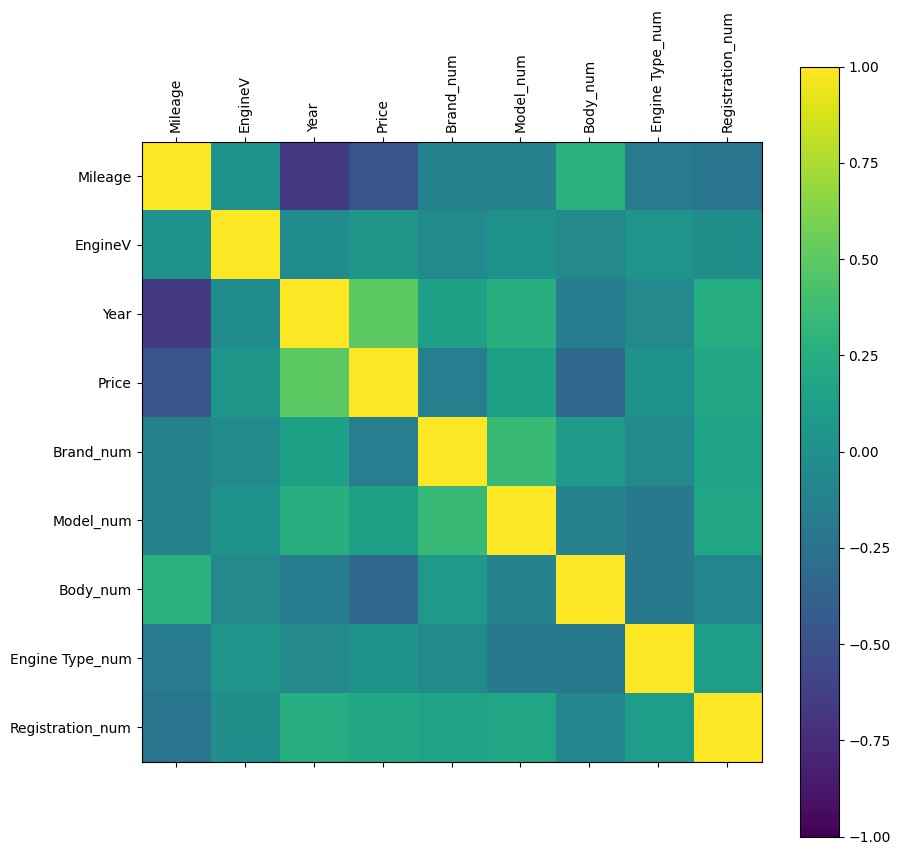

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
correlation = df.corr(method="pearson")
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1,1,1)
cax = ax.matshow(correlation, vmin=-1, vmax=1)
fig.colorbar(cax)
ticks = np.arange(0, len(df.columns), 1)
ax.set_xticks(ticks)
plt.xticks(rotation=90)
ax.set_yticks(ticks)
ax.set_xticklabels(df.columns)
ax.set_yticklabels(df.columns)
plt.show()

In [ ]:
df.columns

Index(['Mileage', 'EngineV', 'Year', 'Price', 'Brand_num', 'Model_num',
       'Body_num', 'Engine Type_num', 'Registration_num'],
      dtype='object')

In [ ]:
X = df[['Mileage', 'EngineV', 'Year','Brand_num', 'Model_num',
       'Body_num', 'Engine Type_num', 'Registration_num']]
Y = df["Price"]

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, Y_train)


LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)
print(
    "MAE:", mae,
    "\nMSE:", mse,
    "\nRMSE:", rmse
)


MAE: 11248.865378682614 
MSE: 391777053.2022202 
RMSE: 19793.358815578023


In [ ]:
year = 2015
milage